Epoch 1, Loss: 0.0273
Epoch 2, Loss: 0.0158
Epoch 3, Loss: 0.0129
Epoch 4, Loss: 0.0113
Epoch 5, Loss: 0.0101
Epoch 6, Loss: 0.0092
Epoch 7, Loss: 0.0087
Epoch 8, Loss: 0.0082
Epoch 9, Loss: 0.0076
Epoch 10, Loss: 0.0072


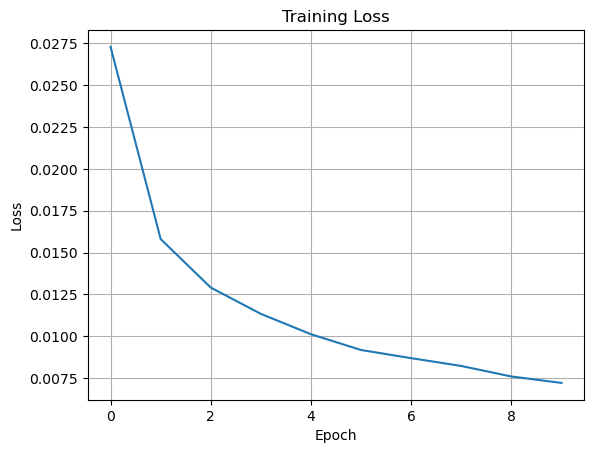

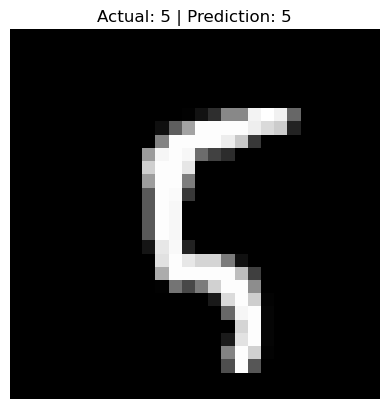

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
from sklearn.preprocessing import OneHotEncoder

# Load MNIST dataset
(X_train, y_train), (_, _) = mnist.load_data()

# Normalize and reshape
X_train = X_train.reshape(-1, 784) / 255.0

# One-hot encode labels
encoder = OneHotEncoder(sparse_output=False)
y_train = encoder.fit_transform(y_train.reshape(-1, 1))

# Network architecture
input_size = 784
hidden_size = 64
output_size = 10

# Initialize weights and biases
W1 = np.random.randn(input_size, hidden_size) * 0.01
b1 = np.zeros((1, hidden_size))

W2 = np.random.randn(hidden_size, output_size) * 0.01
b2 = np.zeros((1, output_size))

# Activation function
sigmoid = lambda x: 1 / (1 + np.exp(-x))

# Derivative of sigmoid
sigmoid_deriv = lambda x: x * (1 - x)

# Loss function
loss_fn = lambda y, y_hat: -np.mean(y * np.log(y_hat + 1e-8))

# Training settings
epochs = 10
lr = 0.1

losses = []

# Training
for epoch in range(epochs):

    total_loss = 0

    for i in range(X_train.shape[0]):

        x = X_train[i:i+1]
        y = y_train[i:i+1]

        # Forward propagation
        z1 = x @ W1 + b1
        a1 = sigmoid(z1)

        z2 = a1 @ W2 + b2
        a2 = sigmoid(z2)

        # Calculate loss
        loss = loss_fn(y, a2)
        total_loss += loss

        # Backpropagation
        dz2 = a2 - y
        dW2 = a1.T @ dz2
        db2 = dz2

        dz1 = (dz2 @ W2.T) * sigmoid_deriv(a1)
        dW1 = x.T @ dz1
        db1 = dz1

        # Update weights and biases
        W2 -= lr * dW2
        b2 -= lr * db2

        W1 -= lr * dW1
        b1 -= lr * db1

    # Average loss
    epoch_loss = total_loss / X_train.shape[0]
    losses.append(epoch_loss)

    print(f"Epoch {epoch + 1}, Loss: {epoch_loss:.4f}")


# Plot training loss
plt.plot(losses)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()


# Prediction function
def predict(img):

    # img is already normalized
    img = img.reshape(1, 784)

    a1 = sigmoid(img @ W1 + b1)
    a2 = sigmoid(a1 @ W2 + b2)

    return np.argmax(a2)


# Test one image
idx = 100

plt.imshow(X_train[idx].reshape(28, 28), cmap="gray")
plt.title(f"Actual: {np.argmax(y_train[idx])} | Prediction: {predict(X_train[idx])}")
plt.axis("off")
plt.show()